## FCMB Stock Prediction
We have tried using sector returns to make predictions. We will now try to use just one stock data. FCMB

In [1]:
import pandas as pd

In [2]:
fcmb=pd.read_csv('stock_data/FCMB.csv')

In [3]:
fcmb

,id,symbol,trade_date,open_price,high_price,low_price,close_price,volume,created_at
0,42826,FCMB,2017-01-03,1.10,NaN,NaN,1.10,17981719,2026-04-08T02:41:25.765521+00:00
1,43386,FCMB,2017-01-04,1.11,NaN,NaN,1.11,1346011,2026-04-08T02:42:20.164398+00:00
2,43496,FCMB,2017-01-05,1.12,NaN,NaN,1.12,5449592,2026-04-08T02:42:22.380516+00:00
3,43606,FCMB,2017-01-06,1.17,NaN,NaN,1.17,35871331,2026-04-08T02:42:23.84796+00:00
4,43696,FCMB,2017-01-09,1.28,NaN,NaN,1.28,9482672,2026-04-08T02:42:26.938159+00:00
...,...,...,...,...,...,...,...,...,...
2258,298059,FCMB,2026-07-13,10.10,NaN,NaN,10.10,102235313,2026-07-13T15:10:02.995074+00:00
2259,298497,FCMB,2026-07-14,10.80,NaN,NaN,10.80,16118425,2026-07-14T15:10:03.094441+00:00
2260,298935,FCMB,2026-07-15,10.50,NaN,NaN,10.50,6351340,2026-07-15T15:10:03.078609+00:00
2261,299373,FCMB,2026-07-16,10.50,NaN,NaN,10.50,5634462,2026-07-16T15:10:03.113936+00:00


In [3]:
fcmb=fcmb.drop(columns=['high_price','low_price'])

In [4]:
fcmb.rename(columns={'trade_date':'date'},inplace=True)

In [5]:
fcmb['date']=pd.to_datetime(fcmb['date'])
fcmb.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           2263 non-null   int64         
 1   symbol       2263 non-null   str           
 2   date         2263 non-null   datetime64[us]
 3   open_price   2262 non-null   float64       
 4   close_price  2263 non-null   float64       
 5   volume       2263 non-null   int64         
 6   created_at   2263 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 123.9 KB


lets try to include seasonality.

In [6]:
fcmb['month']=fcmb['date'].dt.month
fcmb['quarter']=fcmb['date'].dt.quarter
fcmb['year']=fcmb['date'].dt.year

In [7]:
fcmb

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42826,FCMB,2017-01-03,1.10,1.10,17981719,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43386,FCMB,2017-01-04,1.11,1.11,1346011,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43496,FCMB,2017-01-05,1.12,1.12,5449592,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43606,FCMB,2017-01-06,1.17,1.17,35871331,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43696,FCMB,2017-01-09,1.28,1.28,9482672,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298059,FCMB,2026-07-13,10.10,10.10,102235313,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298497,FCMB,2026-07-14,10.80,10.80,16118425,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298935,FCMB,2026-07-15,10.50,10.50,6351340,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299373,FCMB,2026-07-16,10.50,10.50,5634462,2026-07-16T15:10:03.113936+00:00,7,3,2026


In [8]:
fcmb.close_price.describe()

count    2263.000000
mean        4.605038
std         3.497623
min         0.930000
25%         1.840000
50%         3.060000
75%         7.600000
max        13.900000
Name: close_price, dtype: float64

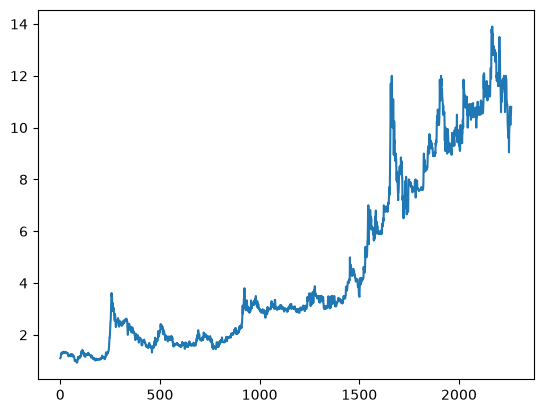

In [9]:
import matplotlib.pyplot as plt

plt.plot(fcmb['close_price'])
plt.show()

In [10]:
fcmb['returns']=fcmb['close_price'].pct_change()*100

In [11]:
fcmb

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,42826,FCMB,2017-01-03,1.10,1.10,17981719,2026-04-08T02:41:25.765521+00:00,1,1,2017,NaN
1,43386,FCMB,2017-01-04,1.11,1.11,1346011,2026-04-08T02:42:20.164398+00:00,1,1,2017,0.909091
2,43496,FCMB,2017-01-05,1.12,1.12,5449592,2026-04-08T02:42:22.380516+00:00,1,1,2017,0.900901
3,43606,FCMB,2017-01-06,1.17,1.17,35871331,2026-04-08T02:42:23.84796+00:00,1,1,2017,4.464286
4,43696,FCMB,2017-01-09,1.28,1.28,9482672,2026-04-08T02:42:26.938159+00:00,1,1,2017,9.401709
...,...,...,...,...,...,...,...,...,...,...,...
2258,298059,FCMB,2026-07-13,10.10,10.10,102235313,2026-07-13T15:10:02.995074+00:00,7,3,2026,-6.481481
2259,298497,FCMB,2026-07-14,10.80,10.80,16118425,2026-07-14T15:10:03.094441+00:00,7,3,2026,6.930693
2260,298935,FCMB,2026-07-15,10.50,10.50,6351340,2026-07-15T15:10:03.078609+00:00,7,3,2026,-2.777778
2261,299373,FCMB,2026-07-16,10.50,10.50,5634462,2026-07-16T15:10:03.113936+00:00,7,3,2026,0.000000


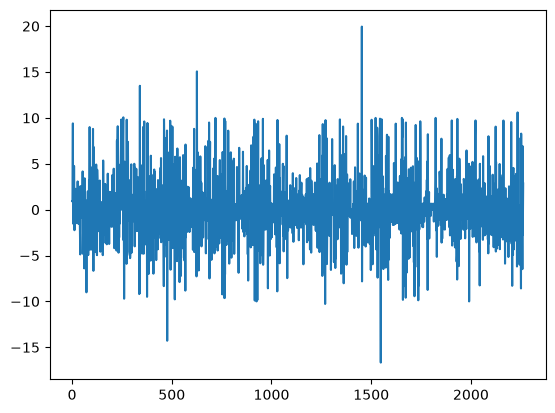

In [12]:
plt.plot(fcmb['returns'])
plt.show()

In [13]:
fcmb2=fcmb.dropna()

## AUTOCORRELATION

In [14]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(fcmb2['returns'])
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-36.45029984903722), 0.0, 1, 2259, {'1%': np.float64(-3.433248072725654), '5%': np.float64(-2.8628202931061955), '10%': np.float64(-2.567451559747925)}, np.float64(11620.172519048374))
stationary


It is stationary.

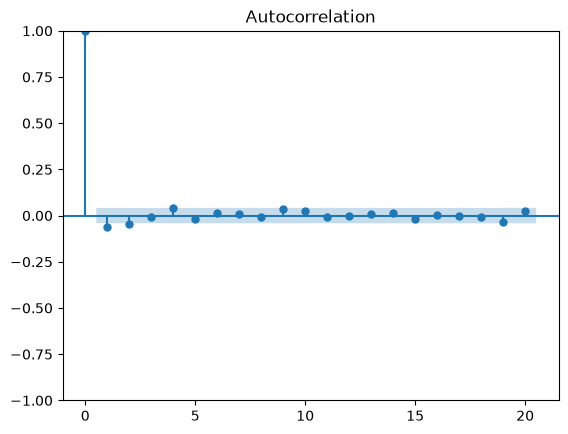

In [15]:
# Autocorrelation of the differenced data
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
plot_acf(fcmb2.returns, lags=20) ## acf is short for autocorrelation function
plt.show()

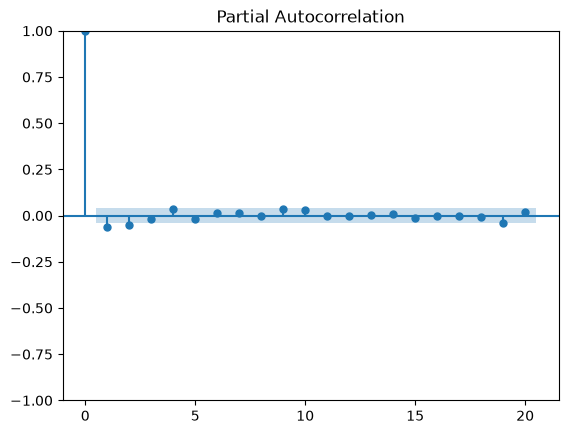

In [17]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(fcmb2.returns, lags = 20)
plt.show()

In [16]:

from sklearn.metrics import r2_score
from statsmodels.regression.linear_model import yule_walker

# Apply a grid search to find the order that gives the best R2 score on the test data

def evaluate(order):
    train = list(fcmb2['returns'])[:-10]
    test = list(fcmb2['returns'])[-10:]

    coefficients, sigma = yule_walker(train, order = order)

    # Make a list of differenced values
    val_list = list(train)

    # Reverse the list to corresponds with the order of coefs
    val_list.reverse()

    # Define the number of years to predict
    n_steps = 10

    # For each day to predict
    for i in range(n_steps):
        # Compute the new value
        new_val = 0
        for j in range(len(coefficients)):
            new_val += coefficients[j] * val_list[j]

        # Insert the new value at the beginning of the list
        val_list.insert(0, new_val)

    # Redo the reverse to have the order of time
    val_list.reverse()
    new_val_list= val_list

    # Plot the newly obtained list
    test_validation = pd.DataFrame({
        'original': list(fcmb2['returns']),
        'test_pred': new_val_list 
    })
    
    return r2_score(test_validation.iloc[-10:, 0], test_validation.iloc[-10:, 1])



In [17]:
# For each order between 1 and 30, fit and evaluate the model
orders = []
r2scores = []
for order in range(1, 31):
    orders.append(order)
    r2scores.append(evaluate(order))

# Create a results data frame
results =pd.DataFrame({'orders': orders,'scores': r2scores})

# Show the order with best R2 score
results[results['scores'] == results.max()['scores']]

,orders,scores
25,26,-0.090391


In [18]:
results

,orders,scores
0,1,-0.102897
1,2,-0.120196
2,3,-0.111386
3,4,-0.116213
4,5,-0.116718
5,6,-0.133011
6,7,-0.120252
7,8,-0.117807
8,9,-0.173967
9,10,-0.139639


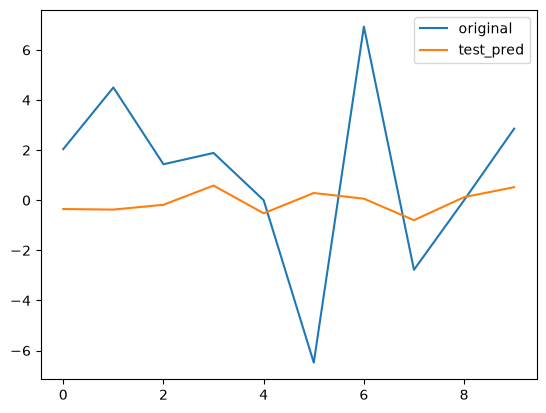

In [21]:
train = list(fcmb2['returns'])[:-10]
test = list(fcmb2['returns'])[-10:]

coefficients, sigma = yule_walker(train, order = 26)

# Make a list of differenced values
val_list = list(train)

# Reverse the list to corresponds with the order of coefs
val_list.reverse()

# Define the number of years to predict
n_steps = 10

# For each day to predict
for i in range(n_steps):
    # Compute the new value
    new_val = 0
    for j in range(len(coefficients)):
        new_val += coefficients[j] * val_list[j]

    # Insert the new value at the beginning of the list
    val_list.insert(0, new_val)

# Redo the reverse to have the order of time
val_list.reverse()
new_val_list= val_list

# Plot the newly obtained list
test_validation = pd.DataFrame({
    'original': list(fcmb2['returns']),
    'test_pred': new_val_list 
})

r2_score(test_validation.iloc[-10:, 0], test_validation.iloc[-10:, 1])

plt.plot(list(fcmb2['returns'])[-10:])
plt.plot(new_val_list[-10:])
plt.legend(test_validation.columns)
plt.show()

AR performance is not good. Lets head straight to ARIMA.

## ARIMA

In this case we will use the close_price.

In [22]:
fcmb2

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
1,43386,FCMB,2017-01-04,1.11,1.11,1346011,2026-04-08T02:42:20.164398+00:00,1,1,2017,0.909091
2,43496,FCMB,2017-01-05,1.12,1.12,5449592,2026-04-08T02:42:22.380516+00:00,1,1,2017,0.900901
3,43606,FCMB,2017-01-06,1.17,1.17,35871331,2026-04-08T02:42:23.84796+00:00,1,1,2017,4.464286
4,43696,FCMB,2017-01-09,1.28,1.28,9482672,2026-04-08T02:42:26.938159+00:00,1,1,2017,9.401709
5,43806,FCMB,2017-01-10,1.30,1.30,37135120,2026-04-08T02:42:29.227202+00:00,1,1,2017,1.562500
...,...,...,...,...,...,...,...,...,...,...,...
2258,298059,FCMB,2026-07-13,10.10,10.10,102235313,2026-07-13T15:10:02.995074+00:00,7,3,2026,-6.481481
2259,298497,FCMB,2026-07-14,10.80,10.80,16118425,2026-07-14T15:10:03.094441+00:00,7,3,2026,6.930693
2260,298935,FCMB,2026-07-15,10.50,10.50,6351340,2026-07-15T15:10:03.078609+00:00,7,3,2026,-2.777778
2261,299373,FCMB,2026-07-16,10.50,10.50,5634462,2026-07-16T15:10:03.113936+00:00,7,3,2026,0.000000


In [19]:
# Applying an ADF test to the differenced data
from statsmodels.tsa.stattools import adfuller

result = adfuller(fcmb2['returns'])

pvalue = result[1]

if pvalue < 0.05:
    print('stationary', result[1])
else:
    print('not stationary',result[1])

stationary 0.0


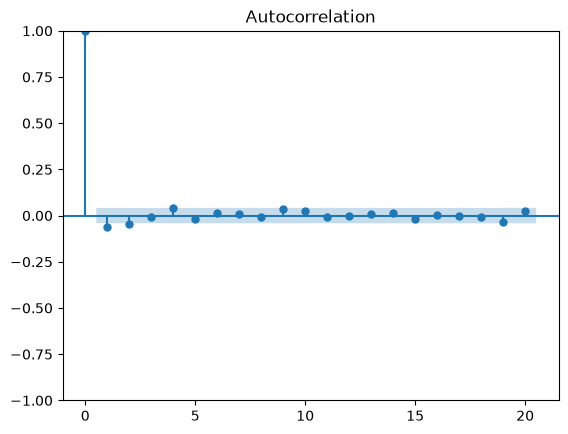

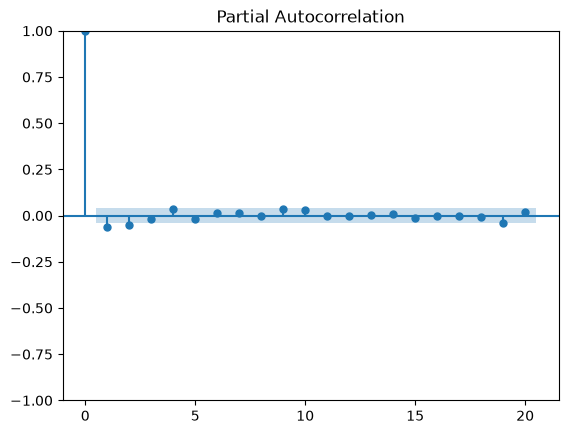

In [20]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(fcmb2['returns'], lags=20)
plot_pacf(fcmb2['returns'], lags=20)
plt.show()

In [38]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings('ignore')

data_array = fcmb2[['close_price']].values

avg_errors = []

for p in range(6):
    for q in range(6):
        for i in range(3):
            errors = []
            tscv = TimeSeriesSplit(test_size=10)

            for train_index, test_index in tscv.split(data_array):
                X_train = data_array[train_index]
                X_test = data_array[test_index]
                X_test_orig = X_test.copy()
                fcst = []

                for step in range(10):
                    try:
                        mod = ARIMA(X_train, order=(p, i, q))
                        res = mod.fit()

                        # Convert forecast from array to scalar
                        forecast = res.forecast(steps=1)[0]
                        fcst.append(forecast)

                    except Exception as e:
                        print(f"Error for p={p}, i={i}, q={q}, step={step}: {e}")

                        # Use a scalar here as well
                        fcst.append(np.nan)

                    # Add actual observation to training data
                    X_train = np.concatenate(
                        (X_train, X_test[0:1, :])
                    )

                    # Remove first test observation
                    X_test = X_test[1:]

                # Convert actual values to 1D
                y_true = X_test_orig.ravel()

                # Convert forecasts to 1D
                y_pred = np.array(fcst)

                # Don't calculate R² if a model failed
                if np.isnan(y_pred).any():
                    errors.append(np.nan)
                else:
                    errors.append(r2_score(y_true, y_pred))

            pq_result = [p, i, q, np.nanmean(errors)]
            print(pq_result)
            avg_errors.append(pq_result)

[0, 0, 0, np.float64(-316.6134728775325)]
[0, 1, 0, np.float64(-0.08036767238274697)]
[0, 2, 0, np.float64(-1.5879439116168033)]
[0, 0, 1, np.float64(-84.40213091010204)]
[0, 1, 1, np.float64(-0.06353893010123635)]
[0, 2, 1, np.float64(-0.07933612231412376)]
[0, 0, 2, np.float64(-32.02286604787969)]
[0, 1, 2, np.float64(-0.06161365817597366)]
[0, 2, 2, np.float64(-0.06207206682662232)]
[0, 0, 3, np.float64(-13.668257523985147)]
[0, 1, 3, np.float64(-0.06560942495503488)]
[0, 2, 3, np.float64(-0.06005058997441903)]
[0, 0, 4, np.float64(-11.047654564774021)]
[0, 1, 4, np.float64(-0.057581426016619995)]
[0, 2, 4, np.float64(-0.0645197041001172)]
[0, 0, 5, np.float64(-5.971790476040569)]
[0, 1, 5, np.float64(-0.05965787905976374)]
[0, 2, 5, np.float64(-0.055991592202048523)]
[1, 0, 0, np.float64(-0.0832341494982433)]
[1, 1, 0, np.float64(-0.06524190355240655)]
[1, 2, 0, np.float64(-0.8144670125834557)]
[1, 0, 1, np.float64(-0.06652509393997652)]
[1, 1, 1, np.float64(-0.0620813323489011)]
[

KeyboardInterrupt: 

We interrupted it because it was taking too long without any signs of improvement

### We will move to SARIMA

buts lets go back a bit to linear regression

In [21]:
fcmb2

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
1,43386,FCMB,2017-01-04,1.11,1.11,1346011,2026-04-08T02:42:20.164398+00:00,1,1,2017,0.909091
2,43496,FCMB,2017-01-05,1.12,1.12,5449592,2026-04-08T02:42:22.380516+00:00,1,1,2017,0.900901
3,43606,FCMB,2017-01-06,1.17,1.17,35871331,2026-04-08T02:42:23.84796+00:00,1,1,2017,4.464286
4,43696,FCMB,2017-01-09,1.28,1.28,9482672,2026-04-08T02:42:26.938159+00:00,1,1,2017,9.401709
5,43806,FCMB,2017-01-10,1.30,1.30,37135120,2026-04-08T02:42:29.227202+00:00,1,1,2017,1.562500
...,...,...,...,...,...,...,...,...,...,...,...
2258,298059,FCMB,2026-07-13,10.10,10.10,102235313,2026-07-13T15:10:02.995074+00:00,7,3,2026,-6.481481
2259,298497,FCMB,2026-07-14,10.80,10.80,16118425,2026-07-14T15:10:03.094441+00:00,7,3,2026,6.930693
2260,298935,FCMB,2026-07-15,10.50,10.50,6351340,2026-07-15T15:10:03.078609+00:00,7,3,2026,-2.777778
2261,299373,FCMB,2026-07-16,10.50,10.50,5634462,2026-07-16T15:10:03.113936+00:00,7,3,2026,0.000000


train_accuracy:  0.7096610614607173 ,  test accuracy:  -7.58176909158909


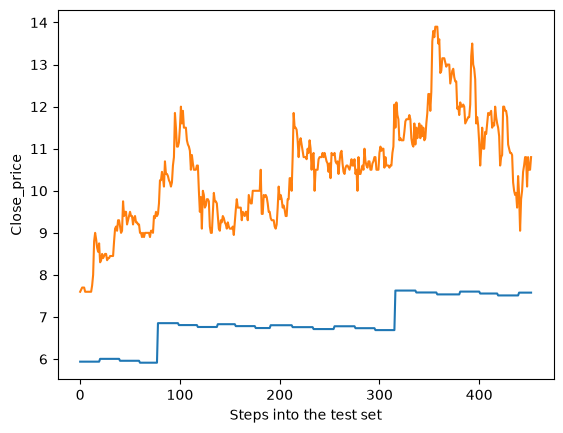

In [40]:
# Create X and y objects
X = fcmb2[['year', 'month', 'quarter']]
y = fcmb2['close_price']
# Create Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, 
random_state=12345,shuffle=False)
# Fit model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

my_lm = LinearRegression()
my_lm.fit(X = X_train, y = y_train)

train_fcst = my_lm.predict(X_train)
test_fcst = my_lm.predict(X_test)

train_r2 = r2_score(y_train, train_fcst)
test_r2 = r2_score(y_test, test_fcst)

print('train_accuracy: ',train_r2,',  test accuracy: ', test_r2)
# Plot result
plt.plot(list(test_fcst))
plt.plot(list(y_test))
plt.xlabel('Steps into the test set')
plt.ylabel('Close_price')
plt.show()

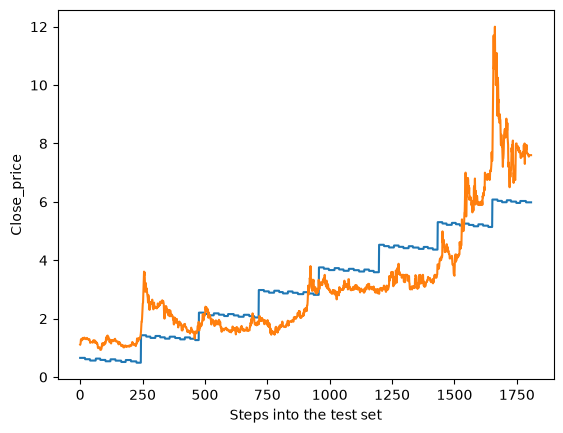

In [41]:

plt.plot(list(train_fcst))
plt.plot(list(y_train))
plt.xlabel('Steps into the test set')
plt.ylabel('Close_price')
plt.show()

let us apply lag to lag 20

In [42]:
fcmb_lag=fcmb2.copy()

In [43]:
fcmb_lag['close_price_L1']=fcmb_lag['close_price'].shift(1)
fcmb_lag['close_price_L2']=fcmb_lag['close_price'].shift(2)
fcmb_lag['close_price_L5']=fcmb_lag['close_price'].shift(5)
fcmb_lag['close_price_L10']=fcmb_lag['close_price'].shift(10)
fcmb_lag['close_price_L15']=fcmb_lag['close_price'].shift(15)
fcmb_lag['close_price_L20']=fcmb_lag['close_price'].shift(20)
fcmb_lag['close_price_L30']=fcmb_lag['close_price'].shift(30)
fcmb_lag['close_price_L45']=fcmb_lag['close_price'].shift(45)
fcmb_lag['close_price_L60']=fcmb_lag['close_price'].shift(60)
fcmb_lag['close_price_L90']=fcmb_lag['close_price'].shift(90)

fcmb_lag=fcmb_lag.dropna()
fcmb_lag.shape


(2171, 21)

In [45]:
fcmb_lag.columns

Index(['id', 'symbol', 'date', 'open_price', 'close_price', 'volume',
       'created_at', 'month', 'quarter', 'year', 'returns', 'close_price_L1',
       'close_price_L2', 'close_price_L5', 'close_price_L10',
       'close_price_L15', 'close_price_L20', 'close_price_L30',
       'close_price_L45', 'close_price_L60', 'close_price_L90'],
      dtype='str')

train_accuracy:  0.9952837696873317 ,  test accuracy:  0.9329020080606281


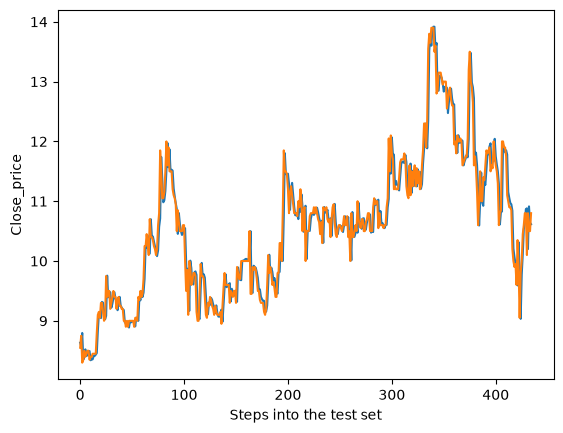

In [54]:
# Create X and y objects
X = fcmb_lag[['year', 'month', 'quarter','close_price_L1',
       'close_price_L2', 'close_price_L5', 'close_price_L10',
       'close_price_L15', 'close_price_L20','close_price_L30', 'close_price_L45','close_price_L60', 'close_price_L90'
    ]]

y = fcmb_lag['close_price']

# Create Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, 
random_state=12345,shuffle=False)

# Fit model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

my_lm = LinearRegression()
my_lm.fit(X = X_train, y = y_train)

train_fcst = my_lm.predict(X_train)
test_fcst = my_lm.predict(X_test)

train_r2 = r2_score(y_train, train_fcst)
test_r2 = r2_score(y_test, test_fcst)

print('train_accuracy: ',train_r2,',  test accuracy: ', test_r2)
# Plot result
plt.plot(list(test_fcst))
plt.plot(list(y_test))
plt.xlabel('Steps into the test set')
plt.ylabel('Close_price')
plt.show()

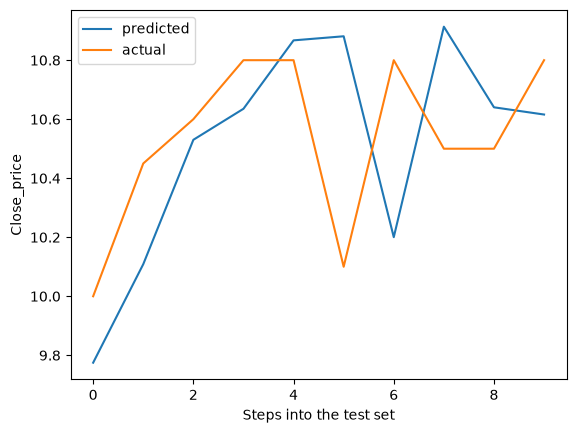

In [55]:
# Plot result
plt.plot(list(test_fcst)[-10:])
plt.plot(list(y_test)[-10:])
plt.xlabel('Steps into the test set')
plt.ylabel('Close_price')
plt.legend(['predicted','actual'])
plt.show()

Lagging basically uses previous to predict next. it is almost stochastic.

Lets get back to ARIMA. to find the best p,d,q

In [22]:
import pmdarima as pm

# This automatically finds the best p, d, and q for your trended data
model = pm.auto_arima(fcmb2['close_price'], 
                      d=None,           # Let the algorithm find the best 'd'
                      max_p=10,
                      max_d=10, 
                      max_q=10,
                      seasonal=False,   # Set to True if you also have seasonal patterns
                      stepwise=True)

print(model.summary()) # This will show you the chosen p, d, q values


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2261
Model:               SARIMAX(2, 1, 1)   Log Likelihood                 637.302
Date:                Sat, 29 Aug 2026   AIC                          -1264.604
Time:                        15:15:38   BIC                          -1235.988
Sample:                             0   HQIC                         -1254.162
                               - 2261                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0002   7.46e-05      2.178      0.029    1.63e-05       0.000
ar.L1          0.9004      0.012     73.906      0.000       0.877       0.924
ar.L2          0.0620      0.011      5.565      0.0

In [27]:
model = pm.auto_arima(fcmb2['returns'], 
                      d=None,           # Let the algorithm find the best 'd'
                      max_p=10,
                      max_d=10, 
                      max_q=10,
                      seasonal=False,   # Set to True if you also have seasonal patterns
                      stepwise=True)

print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2261
Model:               SARIMAX(0, 0, 2)   Log Likelihood               -5873.928
Date:                Fri, 28 Aug 2026   AIC                          11755.857
Time:                        13:04:44   BIC                          11778.751
Sample:                             0   HQIC                         11764.211
                               - 2261                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1537      0.062      2.474      0.013       0.032       0.275
ma.L1         -0.0672      0.015     -4.386      0.000      -0.097      -0.037
ma.L2         -0.0451      0.017     -2.608      0.0

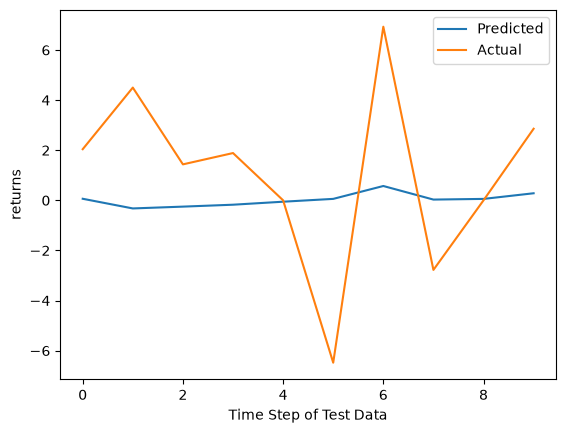

-0.054625333661852515

In [30]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# Plot the final result
data_array = fcmb2[['returns']].values

X_train, X_test = data_array[:-10], data_array[-10:]
X_test_orig = X_test

fcst = []
for step in range(10):
    mod = ARIMA(X_train, order=(0,0,2))
    res = mod.fit()
    fcst.append(res.forecast(steps=1))
    X_train = np.concatenate((X_train, X_test[0:1,:]))
    X_test = X_test[1:]
plt.plot(fcst)
plt.plot(X_test_orig)
plt.legend(['Predicted', 'Actual'])
plt.ylabel('returns')
plt.xlabel('Time Step of Test Data')
plt.show()
r2_score(X_test_orig,fcst)

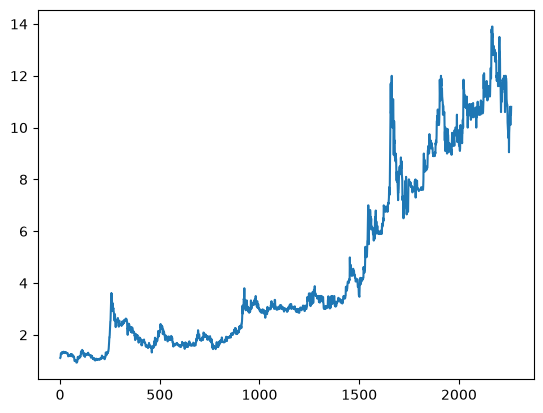

In [31]:
plt.plot(fcmb2.close_price)
plt.show()

In [32]:
from pmdarima import auto_arima

# Fit the optimal auto_arima model
model = auto_arima(
    y=fcmb2['close_price'], # Your time series data
    max_p=10, max_q=10,     # Maximum bounds for searching p and q
    seasonal=True,          # Enable support for seasonal data (SARIMA)
    m=12,                   # Period for seasonal differencing (e.g., 12 for monthly data)
    stepwise=True,          # Uses an intelligent stepwise algorithm for speed
    trace=True              # Prints feedback on the grid search progress
)

# Summarize the selected model attributes
print(model.summary())

# # Forecast the next 10 steps
# forecast = model.predict(n_periods=10)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=-1251.154, Time=10.69 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-1246.245, Time=0.41 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-1254.443, Time=2.10 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-1255.252, Time=1.78 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-1247.012, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=-1257.226, Time=0.66 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=-1255.251, Time=1.54 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=-1253.226, Time=2.05 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=-1258.667, Time=2.03 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=-1256.715, Time=4.98 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=-1256.718, Time=6.90 sec
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=-1254.668, Time=5.10 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=-1256.418, Time=1.12 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=-1264.604, Time=3.47 sec
 ARI

In [34]:
fcmb2

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
1,43386,FCMB,2017-01-04,1.11,1.11,1346011,2026-04-08T02:42:20.164398+00:00,1,1,2017,0.909091
2,43496,FCMB,2017-01-05,1.12,1.12,5449592,2026-04-08T02:42:22.380516+00:00,1,1,2017,0.900901
3,43606,FCMB,2017-01-06,1.17,1.17,35871331,2026-04-08T02:42:23.84796+00:00,1,1,2017,4.464286
4,43696,FCMB,2017-01-09,1.28,1.28,9482672,2026-04-08T02:42:26.938159+00:00,1,1,2017,9.401709
5,43806,FCMB,2017-01-10,1.30,1.30,37135120,2026-04-08T02:42:29.227202+00:00,1,1,2017,1.562500
...,...,...,...,...,...,...,...,...,...,...,...
2258,298059,FCMB,2026-07-13,10.10,10.10,102235313,2026-07-13T15:10:02.995074+00:00,7,3,2026,-6.481481
2259,298497,FCMB,2026-07-14,10.80,10.80,16118425,2026-07-14T15:10:03.094441+00:00,7,3,2026,6.930693
2260,298935,FCMB,2026-07-15,10.50,10.50,6351340,2026-07-15T15:10:03.078609+00:00,7,3,2026,-2.777778
2261,299373,FCMB,2026-07-16,10.50,10.50,5634462,2026-07-16T15:10:03.113936+00:00,7,3,2026,0.000000


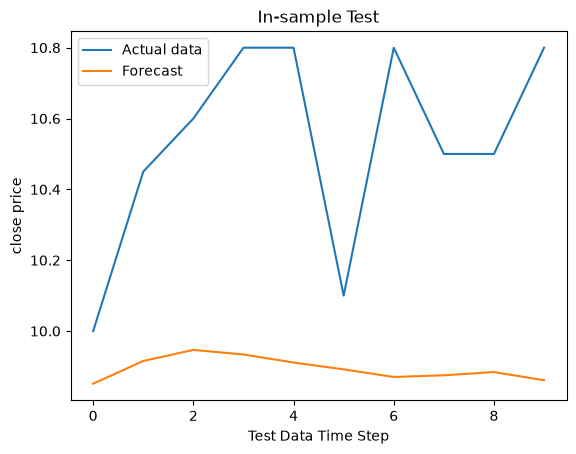

R² Score: -5.275715857594467
RMSE: 0.6952603928969456
MAE: 0.6409011713617859


In [36]:
# Fitting a SARIMA(2,1,0)(0,0,0)[12] model
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')


train = fcmb2['close_price'][:-10]
test = fcmb2['close_price'][-10:]

mod = SARIMAX(train, order=(2,1,1), 
seasonal_order=(1,1,1,10))

res = mod.fit(disp=False)
fcst = res.forecast(steps=10) ## we are forecasting 10 ahead instead of retraining cycle used in last topic. This is because this one will capture the seasonality as well

plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('close price')
plt.xlabel('Test Data Time Step')
plt.title("In-sample Test")
plt.show()

r2 = r2_score(test, fcst)
rmse = np.sqrt(mean_squared_error(test, fcst))
mae = mean_absolute_error(test, fcst)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

In [39]:
from pmdarima import auto_arima

# Fit the optimal auto_arima model
model = auto_arima(
    y=fcmb2['returns'], # Your time series data
    max_p=10, max_q=10,     # Maximum bounds for searching p and q
    seasonal=True,          # Enable support for seasonal data (SARIMA)
    m=12,                   # Period for seasonal differencing (e.g., 12 for monthly data)
    stepwise=True,          # Uses an intelligent stepwise algorithm for speed
    trace=True              # Prints feedback on the grid search progress
)

# Summarize the selected model attributes
print(model.summary())

# # Forecast the next 10 steps
# forecast = model.predict(n_periods=10)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=11762.493, Time=6.54 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=11766.768, Time=0.07 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=11761.737, Time=0.82 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=11760.742, Time=1.16 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=11769.795, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=11758.788, Time=0.32 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=11760.743, Time=0.83 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=11762.758, Time=1.41 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=11757.235, Time=0.60 sec
 ARIMA(1,0,1)(1,0,0)[12] intercept   : AIC=11759.212, Time=1.82 sec
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=11759.212, Time=1.78 sec
 ARIMA(1,0,1)(1,0,1)[12] intercept   : AIC=11761.224, Time=2.58 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=11759.786, Time=0.14 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=11757.541, Time=0.76 sec
 ARIM

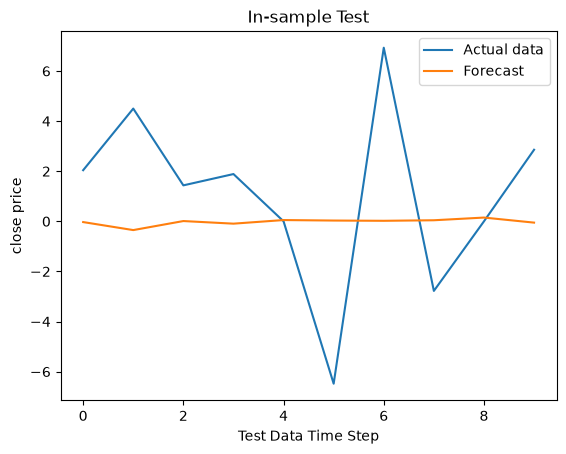

R² Score: -0.12141992100192511
RMSE: 3.7464270618719357
MAE: 2.967736751825376


In [40]:
# Fitting a SARIMA(2,1,0)(0,0,0)[12] model
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')


train = fcmb2['returns'][:-10]
test = fcmb2['returns'][-10:]

mod = SARIMAX(train, order=(0,0,2), 
seasonal_order=(0,0,1,30))

res = mod.fit(disp=False)
fcst = res.forecast(steps=10) ## we are forecasting 10 ahead instead of retraining cycle used in last topic. This is because this one will capture the seasonality as well

plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('close price')
plt.xlabel('Test Data Time Step')
plt.title("In-sample Test")
plt.show()

r2 = r2_score(test, fcst)
rmse = np.sqrt(mean_squared_error(test, fcst))
mae = mean_absolute_error(test, fcst)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

In [41]:
# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(2):
    for i in range(2):
        for q in range(2):
            for P in range(2):
                for D in range(2):
                    for Q in range(2):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,10))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.08627756685385757]
[0, 0, 0, 0, 0, 1, -0.05601092524445539]
[0, 0, 0, 0, 1, 0, -1.0106849033560774]
[0, 0, 0, 0, 1, 1, -0.005218989505543226]
[0, 0, 0, 1, 0, 0, -0.05415951486660209]
[0, 0, 0, 1, 0, 1, -0.0476290728801092]
[0, 0, 0, 1, 1, 0, 0.22316089392393978]
[0, 0, 0, 1, 1, 1, 0.018621143351380542]
[0, 0, 1, 0, 0, 0, -0.10503067847618253]
[0, 0, 1, 0, 0, 1, -0.07209800412892031]
[0, 0, 1, 0, 1, 0, -1.0417657676962073]
[0, 0, 1, 0, 1, 1, -0.0174066359316436]
[0, 0, 1, 1, 0, 0, -0.07014768917893632]
[0, 0, 1, 1, 0, 1, -0.06387924127688072]
[0, 0, 1, 1, 1, 0, 0.20649336102930826]
[0, 0, 1, 1, 1, 1, 0.007193606750517723]
[0, 1, 0, 0, 0, 0, -4.197455329400807]
[0, 1, 0, 0, 0, 1, -4.181791949193994]
[0, 1, 0, 0, 1, 0, -3.8960244306365936]
[0, 1, 0, 0, 1, 1, -4.370519814367229]
[0, 1, 0, 1, 0, 0, -4.180435235459792]
[0, 1, 0, 1, 0, 1, -3.962857256823522]
[0, 1, 0, 1, 1, 0, -2.4109996910852987]
[0, 1, 0, 1, 1, 1, -4.352791237120743]
[0, 1, 1, 0, 0, 0, -0.0632823653654

In [42]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')

In [44]:
result.tail(10)

,p,i,q,P,D,Q,score
39,1,0,0,1,1,1,0.008701
31,0,1,1,1,1,1,0.014867
7,0,0,0,1,1,1,0.018621
54,1,1,0,1,1,0,0.106251
46,1,0,1,1,1,0,0.202813
62,1,1,1,1,1,0,0.205542
14,0,0,1,1,1,0,0.206493
38,1,0,0,1,1,0,0.208372
30,0,1,1,1,1,0,0.220264
6,0,0,0,1,1,0,0.223161


In [ ]:
# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,10))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.08627756685385757]
[0, 0, 0, 0, 0, 1, -0.05601092524445539]
[0, 0, 0, 0, 0, 2, -0.04481990895409682]
[0, 0, 0, 0, 1, 0, -1.0106849033560774]
[0, 0, 0, 0, 1, 1, -0.005218989505543226]
[0, 0, 0, 0, 1, 2, 0.017117738749097278]
[0, 0, 0, 0, 2, 0, -10.703426494996092]
[0, 0, 0, 0, 2, 1, -1.0336855907748737]
[0, 0, 0, 0, 2, 2, 0.07901993484161718]
[0, 0, 0, 1, 0, 0, -0.05415951486660209]
[0, 0, 0, 1, 0, 1, -0.0476290728801092]
[0, 0, 0, 1, 0, 2, -0.046614712533287195]
[0, 0, 0, 1, 1, 0, 0.22316089392393978]
[0, 0, 0, 1, 1, 1, 0.018621143351380542]
[0, 0, 0, 1, 1, 2, -0.00039088557753874653]
[0, 0, 0, 1, 2, 0, -1.0803645301213285]
[0, 0, 0, 1, 2, 1, 0.2170253712707928]
[0, 0, 0, 1, 2, 2, 0.0913170954869208]
[0, 0, 0, 2, 0, 0, -0.04661139968282635]
[0, 0, 0, 2, 0, 1, -0.047199025957398444]
[0, 0, 0, 2, 0, 2, -0.051523928491670645]
[0, 0, 0, 2, 1, 0, 0.11401664729216066]
[0, 0, 0, 2, 1, 1, 0.023132682280268324]
[0, 0, 0, 2, 1, 2, 0.02155010663534096]
[0, 0, 0, 2, 2, 0, -0.

In [46]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')

In [48]:
result.tail(10)

,p,i,q,P,D,Q,score
715,2,2,2,1,2,1,0.264679
712,2,2,2,1,1,0,0.270021
582,2,1,0,1,2,1,0.282854
690,2,2,1,1,2,1,0.283182
578,2,1,0,1,1,0,0.284401
686,2,2,1,1,1,0,0.284611
555,2,0,2,1,2,1,0.286590
723,2,2,2,2,2,1,0.309402
551,2,0,2,1,1,0,0.310843
528,2,0,1,1,2,1,0.311463


We can see [2	0	1	1	2	1] gave an improved score. We can inspect it

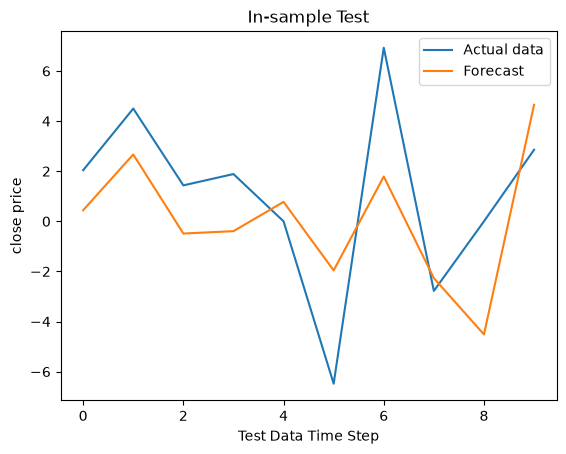

R² Score: 0.3114632837270602
RMSE: 2.9355987933860694
MAE: 2.4893320736952895


In [23]:
# Fitting a SARIMA(2,1,0)(0,0,0)[12] model
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')


train = fcmb2['returns'][:-10]
test = fcmb2['returns'][-10:]

mod = SARIMAX(train, order=(2,0,1), 
seasonal_order=(1,2,1,10))

res = mod.fit(disp=False)
fcst = res.forecast(steps=10) ## we are forecasting 10 ahead instead of retraining cycle used in last topic. This is because this one will capture the seasonality as well

plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('close price')
plt.xlabel('Test Data Time Step')
plt.title("In-sample Test")
plt.show()

r2 = r2_score(test, fcst)
rmse = np.sqrt(mean_squared_error(test, fcst))
mae = mean_absolute_error(test, fcst)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

In [50]:
fcmb2['returns'].describe()

count    2261.000000
mean        0.153896
std         3.262566
min       -16.666667
25%        -1.212121
50%         0.000000
75%         1.333333
max        19.951923
Name: returns, dtype: float64

Why this is a good sign

* `Beating the baseline:` A baseline model that always predicts the average (mean) value of the dataset would have an RMSE equal to the standard deviation (3.2).

* `Adding value:` Because your RMSE (2.4) is lower than the standard deviation (3.2), your model has successfully learned patterns in the data and is performing better than a simple average guess.

We cant use higher iterations the computer has low processing powe we will have to work with this.

NEXT: We will try this with SARIMAX to see if it works. But before that lets run the grid search for close_price.

In [51]:
import numpy as np
# Grid Search on the SARIMA model
train = fcmb2['close_price'][:-10]
test = fcmb2['close_price'][-10:]

scores = []
for p in range(2):
    for i in range(2):
        for q in range(2):
            for P in range(2):
                for D in range(2):
                    for Q in range(2):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,10))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -1440.9117169750045]
[0, 0, 0, 0, 0, 1, -402.3499431578228]
[0, 0, 0, 0, 1, 0, -7.558909444985376]
[0, 0, 0, 0, 1, 1, -4.870996680514879]
[0, 0, 0, 1, 0, 0, -8.001536815953871]
[0, 0, 0, 1, 0, 1, -5.209871120310571]
[0, 0, 0, 1, 1, 0, -5.288069880120861]
[0, 0, 0, 1, 1, 1, -4.425869731166306]
[0, 0, 1, 0, 0, 0, -1335.0605740550054]
[0, 0, 1, 0, 0, 1, -454.56435087116853]
[0, 0, 1, 0, 1, 0, -6.918065828861082]
[0, 0, 1, 0, 1, 1, -1.603905440705847]
[0, 0, 1, 1, 0, 0, -7.64955578147258]
[0, 0, 1, 1, 0, 1, -1.8156442225297567]
[0, 0, 1, 1, 1, 0, -2.291495806465131]
[0, 0, 1, 1, 1, 1, -1.5553423072685915]
[0, 1, 0, 0, 0, 0, -7.013631937682542]
[0, 1, 0, 0, 0, 1, -6.370975569865584]
[0, 1, 0, 0, 1, 0, -39.69133401176446]
[0, 1, 0, 0, 1, 1, -5.730026533609652]
[0, 1, 0, 1, 0, 0, -6.282632869739393]
[0, 1, 0, 1, 0, 1, -5.215481290127025]
[0, 1, 0, 1, 1, 0, -9.94690498466447]
[0, 1, 0, 1, 1, 1, -4.740517316954064]
[0, 1, 1, 0, 0, 0, -8.024397640074676]
[0, 1, 1, 0, 0, 1, -7.

Based on this I will say let us stick to returns. We will apply SARIMAX to see if external Variables can influence this performance, positively.

In [1]:
import pandas as pd

fcmb_n=pd.read_csv('stock_data/FCMB.csv')

In [2]:
fcmb_n=fcmb_n.drop(columns=['high_price','low_price'])

In [3]:
fcmb_n['returns']=fcmb_n['close_price'].pct_change()*100

In [4]:
fcmb_n['volume_lag1']=fcmb_n['volume'].shift(1)
fcmb_n['returns_lag1']=fcmb_n['returns'].shift(1)
fcmb_n['close_price_lag1']=fcmb_n['close_price'].shift(1)
fcmb_n=fcmb_n.dropna()

In [5]:
fcmb_n

,id,symbol,trade_date,open_price,close_price,volume,created_at,returns,volume_lag1,returns_lag1,close_price_lag1
2,43496,FCMB,2017-01-05,1.12,1.12,5449592,2026-04-08T02:42:22.380516+00:00,0.900901,1346011.0,0.909091,1.11
3,43606,FCMB,2017-01-06,1.17,1.17,35871331,2026-04-08T02:42:23.84796+00:00,4.464286,5449592.0,0.900901,1.12
4,43696,FCMB,2017-01-09,1.28,1.28,9482672,2026-04-08T02:42:26.938159+00:00,9.401709,35871331.0,4.464286,1.17
5,43806,FCMB,2017-01-10,1.30,1.30,37135120,2026-04-08T02:42:29.227202+00:00,1.562500,9482672.0,9.401709,1.28
6,43916,FCMB,2017-01-11,1.28,1.28,14301380,2026-04-08T02:42:30.799441+00:00,-1.538462,37135120.0,1.562500,1.30
...,...,...,...,...,...,...,...,...,...,...,...
2258,298059,FCMB,2026-07-13,10.10,10.10,102235313,2026-07-13T15:10:02.995074+00:00,-6.481481,13758897.0,0.000000,10.80
2259,298497,FCMB,2026-07-14,10.80,10.80,16118425,2026-07-14T15:10:03.094441+00:00,6.930693,102235313.0,-6.481481,10.10
2260,298935,FCMB,2026-07-15,10.50,10.50,6351340,2026-07-15T15:10:03.078609+00:00,-2.777778,16118425.0,6.930693,10.80
2261,299373,FCMB,2026-07-16,10.50,10.50,5634462,2026-07-16T15:10:03.113936+00:00,0.000000,6351340.0,-2.777778,10.50


c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is avail

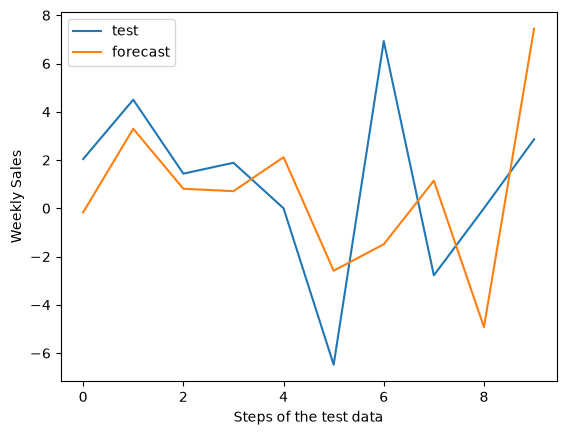

-0.2727956167299803

In [7]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

train = fcmb_n['returns'][:-10]
test = fcmb_n['returns'][-10:]

mod = SARIMAX(
endog=fcmb_n['returns'][:-10],
exog=fcmb_n['returns_lag1'][:-10],
order=(2,0,1), 
seasonal_order=(1,2,1,10),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10, exog = fcmb_n['returns_lag1'][-10:])

plt.plot(list(test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Weekly Sales')
plt.legend(['test', 'forecast'])
plt.show()
r2_score(test, fcst)

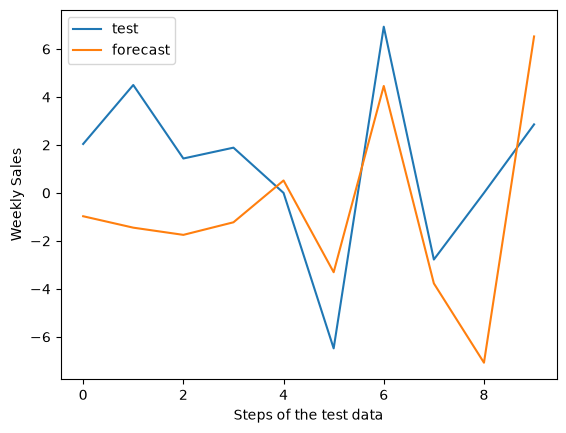

-0.160846262056642

In [ ]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score

train = fcmb_n['returns'][:-10]
test = fcmb_n['returns'][-10:]

mod = SARIMAX(
endog=fcmb_n['returns'][:-10],
exog=fcmb_n['volume_lag1'][:-10],
order=(2,0,1), 
seasonal_order=(1,2,1,10),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10, exog = fcmb_n['volume_lag1'][-10:])

plt.plot(list(test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Weekly Sales')
plt.legend(['test', 'forecast'])
plt.show()
r2_score(test, fcst)

c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is avail

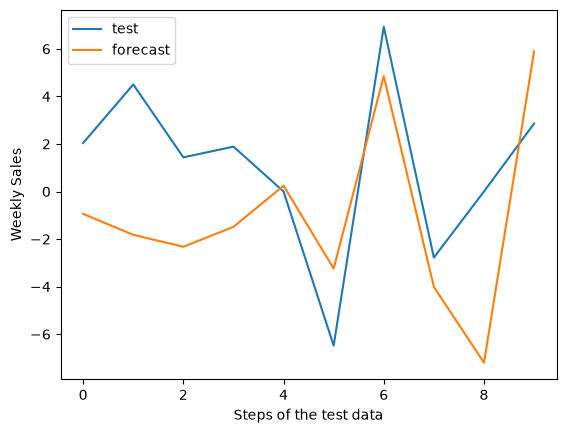

-0.21293508165018382

In [8]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score

train = fcmb_n['returns'][:-10]
test = fcmb_n['returns'][-10:]

mod = SARIMAX(
endog=fcmb_n['returns'][:-10],
exog=fcmb_n[['returns_lag1','volume_lag1']][:-10],
order=(2,0,1), 
seasonal_order=(1,2,1,10),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10, exog = fcmb_n[['returns_lag1','volume_lag1']][-10:])

plt.plot(list(test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Weekly Sales')
plt.legend(['test', 'forecast'])
plt.show()
r2_score(test, fcst)

None of these exogeneous variables improved the model, rather it made it worse. Let us check with `Macro Economic Variables`.

In [9]:
macro_data=pd.read_csv('macroeconomic_data/populated_cleaned_macro_data_adjusted')
macro_data

,Quarter,Month,date,consumer_price_index(CPI)_monthly,Crude Oil Price_monthly,Domestic Production_monthly,Crude Oil Export_monthly,Inflation_allItemsAverage_monthly,Money Supply(M2)_monthly,currency in circulation_monthly,...,gdp_svc_Other Services_quarterly,GDP at Current Basic Prices_quarterly,Net Taxes on Products_quarterly,GDP at Current Market Prices_quarterly,foreign_reserve_Gross(USD)_monthly,foreign_reserve_Liquid(USD)_monthly,Year,Month_idx,foreign_reserve_gross(USD)_daily,foreign_reserve_liquid(USD)_daily
0,Q2,April,2017-04-04,204.456610,52.13,1.60,1.15,17.32,2.230427e+07,1983633.07,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017,4,3.030715e+10,2.963927e+10
1,Q2,April,2017-04-05,204.456610,52.13,1.60,1.15,17.32,2.230427e+07,1983633.07,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017,4,3.031831e+10,2.965163e+10
2,Q2,April,2017-04-06,204.456610,52.13,1.60,1.15,17.32,2.230427e+07,1983633.07,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017,4,3.032576e+10,2.966022e+10
3,Q2,April,2017-04-07,204.456610,52.13,1.60,1.15,17.32,2.230427e+07,1983633.07,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017,4,3.034555e+10,2.968121e+10
4,Q2,April,2017-04-10,204.456610,52.13,1.60,1.15,17.32,2.230427e+07,1983633.07,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017,4,3.036654e+10,2.970295e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2251,Q2,June,2026-06-24,983.932019,112.63,1.53,1.08,18.36,1.292010e+08,5689981.32,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026,6,5.117392e+10,5.050894e+10
2252,Q2,June,2026-06-25,983.932019,112.63,1.53,1.08,18.36,1.292010e+08,5689981.32,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026,6,5.120571e+10,5.054315e+10
2253,Q2,June,2026-06-26,983.932019,112.63,1.53,1.08,18.36,1.292010e+08,5689981.32,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026,6,5.124834e+10,5.058818e+10
2254,Q2,June,2026-06-29,983.932019,112.63,1.53,1.08,18.36,1.292010e+08,5689981.32,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026,6,5.129261e+10,5.063481e+10


In [10]:
macro_data.rename(columns={' gdp_Fishing_quarterly':'gdp_Fishing_quarterly'}, inplace=True)

In [11]:
fcmb_n

,id,symbol,trade_date,open_price,close_price,volume,created_at,returns,volume_lag1,returns_lag1,close_price_lag1
2,43496,FCMB,2017-01-05,1.12,1.12,5449592,2026-04-08T02:42:22.380516+00:00,0.900901,1346011.0,0.909091,1.11
3,43606,FCMB,2017-01-06,1.17,1.17,35871331,2026-04-08T02:42:23.84796+00:00,4.464286,5449592.0,0.900901,1.12
4,43696,FCMB,2017-01-09,1.28,1.28,9482672,2026-04-08T02:42:26.938159+00:00,9.401709,35871331.0,4.464286,1.17
5,43806,FCMB,2017-01-10,1.30,1.30,37135120,2026-04-08T02:42:29.227202+00:00,1.562500,9482672.0,9.401709,1.28
6,43916,FCMB,2017-01-11,1.28,1.28,14301380,2026-04-08T02:42:30.799441+00:00,-1.538462,37135120.0,1.562500,1.30
...,...,...,...,...,...,...,...,...,...,...,...
2258,298059,FCMB,2026-07-13,10.10,10.10,102235313,2026-07-13T15:10:02.995074+00:00,-6.481481,13758897.0,0.000000,10.80
2259,298497,FCMB,2026-07-14,10.80,10.80,16118425,2026-07-14T15:10:03.094441+00:00,6.930693,102235313.0,-6.481481,10.10
2260,298935,FCMB,2026-07-15,10.50,10.50,6351340,2026-07-15T15:10:03.078609+00:00,-2.777778,16118425.0,6.930693,10.80
2261,299373,FCMB,2026-07-16,10.50,10.50,5634462,2026-07-16T15:10:03.113936+00:00,0.000000,6351340.0,-2.777778,10.50


In [12]:
fcmb_n.rename(columns={'trade_date':'date'}, inplace=True)

In [13]:
fcmb_n

,id,symbol,date,open_price,close_price,volume,created_at,returns,volume_lag1,returns_lag1,close_price_lag1
2,43496,FCMB,2017-01-05,1.12,1.12,5449592,2026-04-08T02:42:22.380516+00:00,0.900901,1346011.0,0.909091,1.11
3,43606,FCMB,2017-01-06,1.17,1.17,35871331,2026-04-08T02:42:23.84796+00:00,4.464286,5449592.0,0.900901,1.12
4,43696,FCMB,2017-01-09,1.28,1.28,9482672,2026-04-08T02:42:26.938159+00:00,9.401709,35871331.0,4.464286,1.17
5,43806,FCMB,2017-01-10,1.30,1.30,37135120,2026-04-08T02:42:29.227202+00:00,1.562500,9482672.0,9.401709,1.28
6,43916,FCMB,2017-01-11,1.28,1.28,14301380,2026-04-08T02:42:30.799441+00:00,-1.538462,37135120.0,1.562500,1.30
...,...,...,...,...,...,...,...,...,...,...,...
2258,298059,FCMB,2026-07-13,10.10,10.10,102235313,2026-07-13T15:10:02.995074+00:00,-6.481481,13758897.0,0.000000,10.80
2259,298497,FCMB,2026-07-14,10.80,10.80,16118425,2026-07-14T15:10:03.094441+00:00,6.930693,102235313.0,-6.481481,10.10
2260,298935,FCMB,2026-07-15,10.50,10.50,6351340,2026-07-15T15:10:03.078609+00:00,-2.777778,16118425.0,6.930693,10.80
2261,299373,FCMB,2026-07-16,10.50,10.50,5634462,2026-07-16T15:10:03.113936+00:00,0.000000,6351340.0,-2.777778,10.50


In [14]:
fcmb_n['date']=pd.to_datetime(fcmb_n['date'])
macro_data['date']=pd.to_datetime(macro_data['date'])

In [15]:
## Now we will join the data by date
# Assume both dataframes have an exact 'date' column match
merged_df = pd.merge(fcmb_n, macro_data, on="date", how="left")


In [16]:
merged_df

,id,symbol,date,open_price,close_price,volume,created_at,returns,volume_lag1,returns_lag1,...,gdp_svc_Other Services_quarterly,GDP at Current Basic Prices_quarterly,Net Taxes on Products_quarterly,GDP at Current Market Prices_quarterly,foreign_reserve_Gross(USD)_monthly,foreign_reserve_Liquid(USD)_monthly,Year,Month_idx,foreign_reserve_gross(USD)_daily,foreign_reserve_liquid(USD)_daily
0,43496,FCMB,2017-01-05,1.12,1.12,5449592,2026-04-08T02:42:22.380516+00:00,0.900901,1346011.0,0.909091,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,43606,FCMB,2017-01-06,1.17,1.17,35871331,2026-04-08T02:42:23.84796+00:00,4.464286,5449592.0,0.900901,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,43696,FCMB,2017-01-09,1.28,1.28,9482672,2026-04-08T02:42:26.938159+00:00,9.401709,35871331.0,4.464286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,43806,FCMB,2017-01-10,1.30,1.30,37135120,2026-04-08T02:42:29.227202+00:00,1.562500,9482672.0,9.401709,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,43916,FCMB,2017-01-11,1.28,1.28,14301380,2026-04-08T02:42:30.799441+00:00,-1.538462,37135120.0,1.562500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2283,298059,FCMB,2026-07-13,10.10,10.10,102235313,2026-07-13T15:10:02.995074+00:00,-6.481481,13758897.0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2284,298497,FCMB,2026-07-14,10.80,10.80,16118425,2026-07-14T15:10:03.094441+00:00,6.930693,102235313.0,-6.481481,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2285,298935,FCMB,2026-07-15,10.50,10.50,6351340,2026-07-15T15:10:03.078609+00:00,-2.777778,16118425.0,6.930693,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2286,299373,FCMB,2026-07-16,10.50,10.50,5634462,2026-07-16T15:10:03.113936+00:00,0.000000,6351340.0,-2.777778,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
merged_df=merged_df.dropna()
merged_df

,id,symbol,date,open_price,close_price,volume,created_at,returns,volume_lag1,returns_lag1,...,gdp_svc_Other Services_quarterly,GDP at Current Basic Prices_quarterly,Net Taxes on Products_quarterly,GDP at Current Market Prices_quarterly,foreign_reserve_Gross(USD)_monthly,foreign_reserve_Liquid(USD)_monthly,Year,Month_idx,foreign_reserve_gross(USD)_daily,foreign_reserve_liquid(USD)_daily
63,49702,FCMB,2017-04-04,1.21,1.21,3577401,2026-04-08T02:51:09.86923+00:00,0.000000,1122974.0,0.000000,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017.0,4.0,3.030715e+10,2.963927e+10
64,49794,FCMB,2017-04-05,1.17,1.17,1434694,2026-04-08T02:51:12.308135+00:00,-3.305785,3577401.0,0.000000,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017.0,4.0,3.031831e+10,2.965163e+10
65,49886,FCMB,2017-04-06,1.17,1.17,8573016,2026-04-08T02:51:14.846493+00:00,0.000000,1434694.0,-3.305785,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017.0,4.0,3.032576e+10,2.966022e+10
66,49978,FCMB,2017-04-07,1.15,1.15,13260331,2026-04-08T02:51:17.320635+00:00,-1.709402,8573016.0,0.000000,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017.0,4.0,3.034555e+10,2.968121e+10
67,50069,FCMB,2017-04-10,1.16,1.16,8769520,2026-04-08T02:51:21.583607+00:00,0.869565,13260331.0,-1.709402,...,1237.680000,26028.360000,200.50000,26228.85000,3.029795e+10,2.962647e+10,2017.0,4.0,3.036654e+10,2.970295e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2270,292219,FCMB,2026-06-24,10.00,10.00,19772673,2026-06-24T15:10:03.053149+00:00,-1.960784,15234283.0,-5.990783,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026.0,6.0,5.117392e+10,5.050894e+10
2271,292803,FCMB,2026-06-25,9.90,9.90,14654175,2026-06-25T15:10:02.973562+00:00,-1.000000,19772673.0,-1.960784,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026.0,6.0,5.120571e+10,5.054315e+10
2272,293241,FCMB,2026-06-26,9.95,9.95,12263606,2026-06-26T15:10:03.012808+00:00,0.505051,14654175.0,-1.000000,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026.0,6.0,5.124834e+10,5.058818e+10
2273,293679,FCMB,2026-06-29,9.60,9.60,8212361,2026-06-29T15:10:03.028054+00:00,-3.517588,12263606.0,0.505051,...,1475.904069,110786.347011,2400.52311,113186.87012,4.836401e+10,4.763452e+10,2026.0,6.0,5.129261e+10,5.063481e+10


In [18]:
merged_df.columns

Index(['id', 'symbol', 'date', 'open_price', 'close_price', 'volume',
       'created_at', 'returns', 'volume_lag1', 'returns_lag1',
       'close_price_lag1', 'Quarter', 'Month',
       'consumer_price_index(CPI)_monthly', 'Crude Oil Price_monthly',
       'Domestic Production_monthly', 'Crude Oil Export_monthly',
       'Inflation_allItemsAverage_monthly', 'Money Supply(M2)_monthly',
       'currency in circulation_monthly', 'bank reserves_monthly',
       'netForeignAssets_monthly', 'netDomesticAssets_monthly',
       'netDomesticCredit_monthly', 'creditToGovernment_monthly',
       'creditToPrivateSector_monthly', 'MonetaryPolicyRate_monthly',
       'TreasuryBillRate_monthly', 'Lending_Rate_monthly',
       'Exchange_Rate(USD-EOP)_monthly', 'Premium_Motor_Spirit(PMS)_monthly',
       'GDP_AGRICULTURE(agric)_quarterly',
       'gdp_agric_Crop Production_quarterly', 'gdp_agric_Livestock_quarterly',
       'gdp_agric_Forestry_quarterly', 'gdp_Fishing_quarterly',
       'GDP_INDUSTRY(

In [19]:
## The needed features for this training (Check Cloud AI for explanation)
X_y_finance_features = [
    #target feature
    'returns',
    'close_price',
    'volume',  # consider lagging — see caveat below

    # Prices / inflation
    'consumer_price_index(CPI)_monthly',
    'Inflation_allItemsAverage_monthly',
    'Premium_Motor_Spirit(PMS)_monthly',

    # Oil
    'Crude Oil Price_monthly',
    'Domestic Production_monthly',
    'Crude Oil Export_monthly',

    # Money supply / banking system
    'Money Supply(M2)_monthly',
    'currency in circulation_monthly',
    'bank reserves_monthly',
    'netForeignAssets_monthly',
    'netDomesticAssets_monthly',
    'netDomesticCredit_monthly',
    'creditToGovernment_monthly',
    'creditToPrivateSector_monthly',

    # Interest rates
    'MonetaryPolicyRate_monthly',
    'TreasuryBillRate_monthly',
    'Lending_Rate_monthly',

    # Exchange rate
    'Exchange_Rate(USD-EOP)_monthly',

    # Broad economy GDP
    'GDP_AGRICULTURE(agric)_quarterly',
    'GDP_INDUSTRY(ind)_quarterly',
    'GDP at Current Market Prices_quarterly',

    # Financial sector-specific GDP
    'gdp_svc_FI_Financial Institutions_quarterly',

    # Foreign reserves (pick one frequency — daily shown here)
    'foreign_reserve_gross(USD)_daily',
    'foreign_reserve_liquid(USD)_daily',
]


In [20]:
data=merged_df[X_y_finance_features]
data

,returns,close_price,volume,consumer_price_index(CPI)_monthly,Inflation_allItemsAverage_monthly,Premium_Motor_Spirit(PMS)_monthly,Crude Oil Price_monthly,Domestic Production_monthly,Crude Oil Export_monthly,Money Supply(M2)_monthly,...,MonetaryPolicyRate_monthly,TreasuryBillRate_monthly,Lending_Rate_monthly,Exchange_Rate(USD-EOP)_monthly,GDP_AGRICULTURE(agric)_quarterly,GDP_INDUSTRY(ind)_quarterly,GDP at Current Market Prices_quarterly,gdp_svc_FI_Financial Institutions_quarterly,foreign_reserve_gross(USD)_daily,foreign_reserve_liquid(USD)_daily
63,0.000000,1.21,3577401,204.456610,17.32,149.390000,52.13,1.60,1.15,2.230427e+07,...,14.0,13.60,17.43,306.3500,4686.220000,5767.040000,26228.85000,815.970000,3.030715e+10,2.963927e+10
64,-3.305785,1.17,1434694,204.456610,17.32,149.390000,52.13,1.60,1.15,2.230427e+07,...,14.0,13.60,17.43,306.3500,4686.220000,5767.040000,26228.85000,815.970000,3.031831e+10,2.965163e+10
65,0.000000,1.17,8573016,204.456610,17.32,149.390000,52.13,1.60,1.15,2.230427e+07,...,14.0,13.60,17.43,306.3500,4686.220000,5767.040000,26228.85000,815.970000,3.032576e+10,2.966022e+10
66,-1.709402,1.15,13260331,204.456610,17.32,149.390000,52.13,1.60,1.15,2.230427e+07,...,14.0,13.60,17.43,306.3500,4686.220000,5767.040000,26228.85000,815.970000,3.034555e+10,2.968121e+10
67,0.869565,1.16,8769520,204.456610,17.32,149.390000,52.13,1.60,1.15,2.230427e+07,...,14.0,13.60,17.43,306.3500,4686.220000,5767.040000,26228.85000,815.970000,3.036654e+10,2.970295e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2270,-1.960784,10.00,19772673,983.932019,18.36,1596.245819,112.63,1.53,1.08,1.292010e+08,...,26.5,15.95,19.10,1373.2545,20058.337297,22442.618713,113186.87012,3844.433287,5.117392e+10,5.050894e+10
2271,-1.000000,9.90,14654175,983.932019,18.36,1596.245819,112.63,1.53,1.08,1.292010e+08,...,26.5,15.95,19.10,1373.2545,20058.337297,22442.618713,113186.87012,3844.433287,5.120571e+10,5.054315e+10
2272,0.505051,9.95,12263606,983.932019,18.36,1596.245819,112.63,1.53,1.08,1.292010e+08,...,26.5,15.95,19.10,1373.2545,20058.337297,22442.618713,113186.87012,3844.433287,5.124834e+10,5.058818e+10
2273,-3.517588,9.60,8212361,983.932019,18.36,1596.245819,112.63,1.53,1.08,1.292010e+08,...,26.5,15.95,19.10,1373.2545,20058.337297,22442.618713,113186.87012,3844.433287,5.129261e+10,5.063481e+10


In [21]:
data.corr()

,returns,close_price,volume,consumer_price_index(CPI)_monthly,Inflation_allItemsAverage_monthly,Premium_Motor_Spirit(PMS)_monthly,Crude Oil Price_monthly,Domestic Production_monthly,Crude Oil Export_monthly,Money Supply(M2)_monthly,...,MonetaryPolicyRate_monthly,TreasuryBillRate_monthly,Lending_Rate_monthly,Exchange_Rate(USD-EOP)_monthly,GDP_AGRICULTURE(agric)_quarterly,GDP_INDUSTRY(ind)_quarterly,GDP at Current Market Prices_quarterly,gdp_svc_FI_Financial Institutions_quarterly,foreign_reserve_gross(USD)_daily,foreign_reserve_liquid(USD)_daily
returns,1.000000,0.011812,0.085109,-0.005219,0.010697,-0.015218,0.013319,-0.033193,-0.033193,-0.008096,...,-0.011337,-0.037822,-0.021770,-0.014331,-0.003036,0.001323,-0.009345,-0.007078,-0.022700,-0.023848
close_price,0.011812,1.000000,0.090850,0.975267,0.718265,0.941498,0.332511,-0.459698,-0.459698,0.977009,...,0.919871,0.575701,0.456977,0.939219,0.867917,0.849358,0.942703,0.931277,0.226356,0.219710
volume,0.085109,0.090850,1.000000,0.073888,0.037865,0.076984,0.016742,0.007778,0.007778,0.072881,...,0.070899,0.059230,0.092813,0.063342,0.091680,0.018061,0.094958,0.074451,0.062359,0.063007
consumer_price_index(CPI)_monthly,-0.005219,0.975267,0.073888,1.000000,0.709470,0.938913,0.375995,-0.512593,-0.512593,0.993408,...,0.926271,0.555632,0.418807,0.942293,0.878492,0.870827,0.961467,0.942385,0.213047,0.206704
Inflation_allItemsAverage_monthly,0.010697,0.718265,0.037865,0.709470,1.000000,0.642471,0.360213,-0.540425,-0.540425,0.746231,...,0.764461,0.528143,0.296194,0.796574,0.507435,0.717676,0.561274,0.737271,-0.153135,-0.166334
Premium_Motor_Spirit(PMS)_monthly,-0.015218,0.941498,0.076984,0.938913,0.642471,1.000000,0.270276,-0.300621,-0.300621,0.940199,...,0.926396,0.663997,0.585364,0.921414,0.792128,0.781481,0.899733,0.906764,0.260732,0.252472
Crude Oil Price_monthly,0.013319,0.332511,0.016742,0.375995,0.360213,0.270276,1.000000,-0.585350,-0.585350,0.349511,...,0.251566,0.072344,-0.122648,0.259164,0.215951,0.525015,0.297553,0.354519,0.235315,0.233641
Domestic Production_monthly,-0.033193,-0.459698,0.007778,-0.512593,-0.540425,-0.300621,-0.585350,1.000000,1.000000,-0.489953,...,-0.293811,0.156622,0.413686,-0.391947,-0.419765,-0.701822,-0.420385,-0.438209,0.222329,0.214006
Crude Oil Export_monthly,-0.033193,-0.459698,0.007778,-0.512593,-0.540425,-0.300621,-0.585350,1.000000,1.000000,-0.489953,...,-0.293811,0.156622,0.413686,-0.391947,-0.419765,-0.701822,-0.420385,-0.438209,0.222329,0.214006
Money Supply(M2)_monthly,-0.008096,0.977009,0.072881,0.993408,0.746231,0.940199,0.349511,-0.489953,-0.489953,1.000000,...,0.945928,0.600021,0.440887,0.971839,0.851138,0.863730,0.939999,0.953609,0.187968,0.180601


We wan to try and apply Ridge Regression on the difference in the features

In [22]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

In [33]:
# 1. Differencing X drops the first row
X = data.drop(columns=['returns', 'close_price', 'volume']).diff().dropna()

# 2. Align y to have the exact same index (dates) as X
y = data['returns'].loc[X.index]

Lets now scale it

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Scales the differenced data to mean=0, var=1
    ('ridge', Ridge(alpha=1.0))    # Fits the Ridge regression model
])

tscv = TimeSeriesSplit(n_splits=5, test_size=100)
scores = []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Train the pipeline (scales train data, then fits Ridge)
    ridge_pipeline.fit(X_train, y_train)
    
    # Predict (uses train scales to transform test data, preventing leakage)
    preds = ridge_pipeline.predict(X_test)
    scores.append(r2_score(y_test, preds))

print(f"Mean Out-of-Sample R² Score across folds: {np.mean(scores):.4f}")

Mean Out-of-Sample R² Score across folds: -0.0733


Ridge s still very poor. We will move on from this.

Let us check the correlation between the differenced data and target

In [39]:
X

,consumer_price_index(CPI)_monthly,Inflation_allItemsAverage_monthly,Premium_Motor_Spirit(PMS)_monthly,Crude Oil Price_monthly,Domestic Production_monthly,Crude Oil Export_monthly,Money Supply(M2)_monthly,currency in circulation_monthly,bank reserves_monthly,netForeignAssets_monthly,...,MonetaryPolicyRate_monthly,TreasuryBillRate_monthly,Lending_Rate_monthly,Exchange_Rate(USD-EOP)_monthly,GDP_AGRICULTURE(agric)_quarterly,GDP_INDUSTRY(ind)_quarterly,GDP at Current Market Prices_quarterly,gdp_svc_FI_Financial Institutions_quarterly,foreign_reserve_gross(USD)_daily,foreign_reserve_liquid(USD)_daily
64,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.115502e+07,1.235877e+07
65,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.454250e+06,8.588431e+06
66,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.978923e+07,2.098935e+07
67,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.098835e+07,2.174092e+07
68,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.735417e+07,2.862781e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.187267e+07,3.420560e+07
2271,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.179502e+07,3.420936e+07
2272,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.262456e+07,4.503011e+07
2273,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.427514e+07,4.663058e+07


In [37]:
correlations = X.corrwith(y)
correlations

consumer_price_index(CPI)_monthly             -0.027264
Inflation_allItemsAverage_monthly             -0.000226
Premium_Motor_Spirit(PMS)_monthly             -0.017305
Crude Oil Price_monthly                       -0.001547
Domestic Production_monthly                    0.018355
Crude Oil Export_monthly                       0.018355
Money Supply(M2)_monthly                      -0.012872
currency in circulation_monthly               -0.129353
bank reserves_monthly                          0.019748
netForeignAssets_monthly                       0.016440
netDomesticAssets_monthly                     -0.082952
netDomesticCredit_monthly                     -0.009811
creditToGovernment_monthly                    -0.018407
creditToPrivateSector_monthly                  0.007433
MonetaryPolicyRate_monthly                     0.002997
TreasuryBillRate_monthly                       0.026630
Lending_Rate_monthly                           0.039498
Exchange_Rate(USD-EOP)_monthly                 0

Not much correlation but we can work with SARIMAX.

c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\pc\Downloads\Python_NGX_Project\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is avail

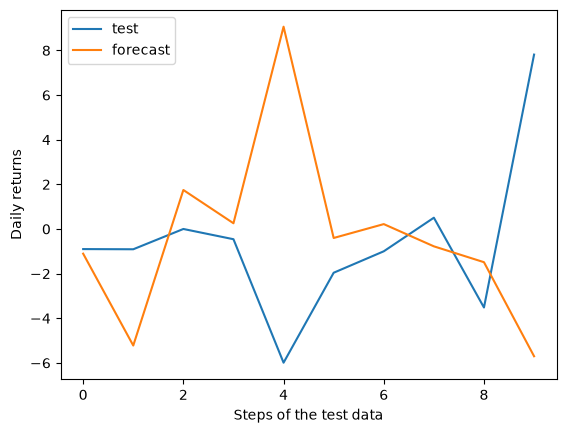

-2.9341595642369662

In [42]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score

train = y[:-10]
test = y[-10:]

mod = SARIMAX(
endog=y[:-10],
exog=X[:-10],
order=(2,0,1), 
seasonal_order=(1,2,1,10),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10, exog = X[-10:])

plt.plot(list(test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Daily returns')
plt.legend(['test', 'forecast'])
plt.show()
r2_score(test, fcst)